# 213. House Robber II
https://leetcode.com/problems/house-robber-ii/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DP (two passes) | $O(n)$ | $O(1)$ | Optimal — rob range [0,n-2] and [1,n-1] |
| DP with array | $O(n)$ | $O(n)$ | Uses extra DP array |

## Methodology

Since houses are arranged in a circle, the first and last houses are adjacent. We break the circle by considering two linear sub-problems: one excluding the last house (indices 0..n-2) and one excluding the first house (indices 1..n-1). We apply the standard House Robber DP on each range and return the maximum. The DP uses two variables (prev and curr) to track the best amounts, giving O(1) space.

## Solutions

### C#

In [ ]:
public class Solution {
    public int Rob(int[] nums) {
        int n = nums.Length;
        if (n == 1) return nums[0];
        return Math.Max(RobRange(nums, 0, n - 2), RobRange(nums, 1, n - 1));
    }

    private int RobRange(int[] nums, int lo, int hi) {
        int prev = 0, curr = 0;
        for (int i = lo; i <= hi; i++) {
            int temp = Math.Max(curr, prev + nums[i]);
            prev = curr;
            curr = temp;
        }
        return curr;
    }
}

### Python

In [ ]:
class Solution:
    def rob(self, nums: list[int]) -> int:
        if len(nums) == 1:
            return nums[0]

        def rob_range(lo: int, hi: int) -> int:
            prev = curr = 0
            for i in range(lo, hi + 1):
                prev, curr = curr, max(curr, prev + nums[i])
            return curr

        return max(rob_range(0, len(nums) - 2), rob_range(1, len(nums) - 1))

### Go

In [ ]:
func rob(nums []int) int {
    n := len(nums)
    if n == 1 {
        return nums[0]
    }
    return max(robRange(nums, 0, n-2), robRange(nums, 1, n-1))
}

func robRange(nums []int, lo, hi int) int {
    prev, curr := 0, 0
    for i := lo; i <= hi; i++ {
        prev, curr = curr, max(curr, prev+nums[i])
    }
    return curr
}

### Rust

In [ ]:
impl Solution {
    pub fn rob(nums: Vec<i32>) -> i32 {
        let n = nums.len();
        if n == 1 {
            return nums[0];
        }
        Self::rob_range(&nums, 0, n - 2).max(Self::rob_range(&nums, 1, n - 1))
    }

    fn rob_range(nums: &[i32], lo: usize, hi: usize) -> i32 {
        let (mut prev, mut curr) = (0, 0);
        for i in lo..=hi {
            let temp = curr.max(prev + nums[i]);
            prev = curr;
            curr = temp;
        }
        curr
    }
}

## Example Scenarios

### 1. Common Case — Four Houses in a Circle
**Input:** `nums = [2, 3, 2, 1]`

Houses form a circle: house 0 and house 3 are neighbors. Range [0..2]: rob 0 and 2 for 2+2=4. Range [1..3]: rob house 1 for 3. Answer = max(4, 3) = 4.

WHY it's tricky: It isn't — validates the two-range decomposition works on a simple circular arrangement.

$\max(\text{robRange}(0,2),\ \text{robRange}(1,3)) = \max(4, 3) = 4$

### 2. Slightly Complex — Alternating High-Low Values
**Input:** `nums = [1, 7, 2, 8, 3, 6]`

Range [0..4] best: indices 1,3 = 7+8 = 15. Range [1..5] best: indices 1,3,5 = 7+8+6 = 21. Since range [1..5] excludes house 0, robbing 1,3,5 is valid (no circular adjacency). Answer = max(15, 21) = 21.

WHY it's tricky: The optimal uses every-other-house from range [1..5], only possible when excluding house 0. Including house 0 would make index 5 adjacent to it in the circle.

$\max(15, 21) = 21. \text{ Optimal set: } \{1, 3, 5\} \text{ with values } \{7, 8, 6\}$

### 3. Edge Case: Time Factor — 100 Alternating Houses
**Input:** `nums = [100, 1, 100, 1, ..., 100, 1]` (100 elements, alternating)

Two linear scans of ~99 elements each. Even at the constraint limit (n=100), this is 198 total iterations. The DP recurrence runs in constant time per step.

WHY it's tricky: The constraint (n ≤ 100) is small enough that time is never a real concern. But the alternating pattern tests that the algorithm correctly picks every other house in each range.

$O(n) = O(100). \text{ Two passes of 99 iterations} = 198 \text{ total comparisons.}$

### 4. Edge Case: Space Factor — Single House
**Input:** `nums = [42]`

Only one house — the circular adjacency is irrelevant. Return nums[0] = 42 directly. No ranges to compute, no DP needed. This is the base case that must be handled before two-range logic.

WHY it's tricky: If you don't handle n=1 separately, the two-range decomposition creates range [0..-1] and [1..0], both empty, returning 0 instead of 42. This off-by-one is a common interview bug.

$n = 1 \Rightarrow \text{return } nums[0] = 42. \text{ Space: } O(1)$

### 5. Almost-Impossible — 100 Houses All at Maximum Value
**Input:** `nums = [400, 400, ..., 400]` (100 elements, all 400)

Every house has value 400. In a circle of 100, we can rob at most 50 non-adjacent houses. Both ranges yield 50 × 400 = 20,000. The sum fits in a 32-bit integer ($2^{31} - 1 = 2{,}147{,}483{,}647$) with room to spare.

WHY it's tricky: With n ≤ 100 and nums[i] ≤ 400, the max sum is 50 × 400 = 20,000. No overflow risk. But verifying this boundary matters — in variants with larger constraints, overflow becomes real.

$\max\ \text{sum} = \lfloor n/2 \rfloor \times \max(nums_i) = 50 \times 400 = 20{,}000 \ll 2^{31}-1$


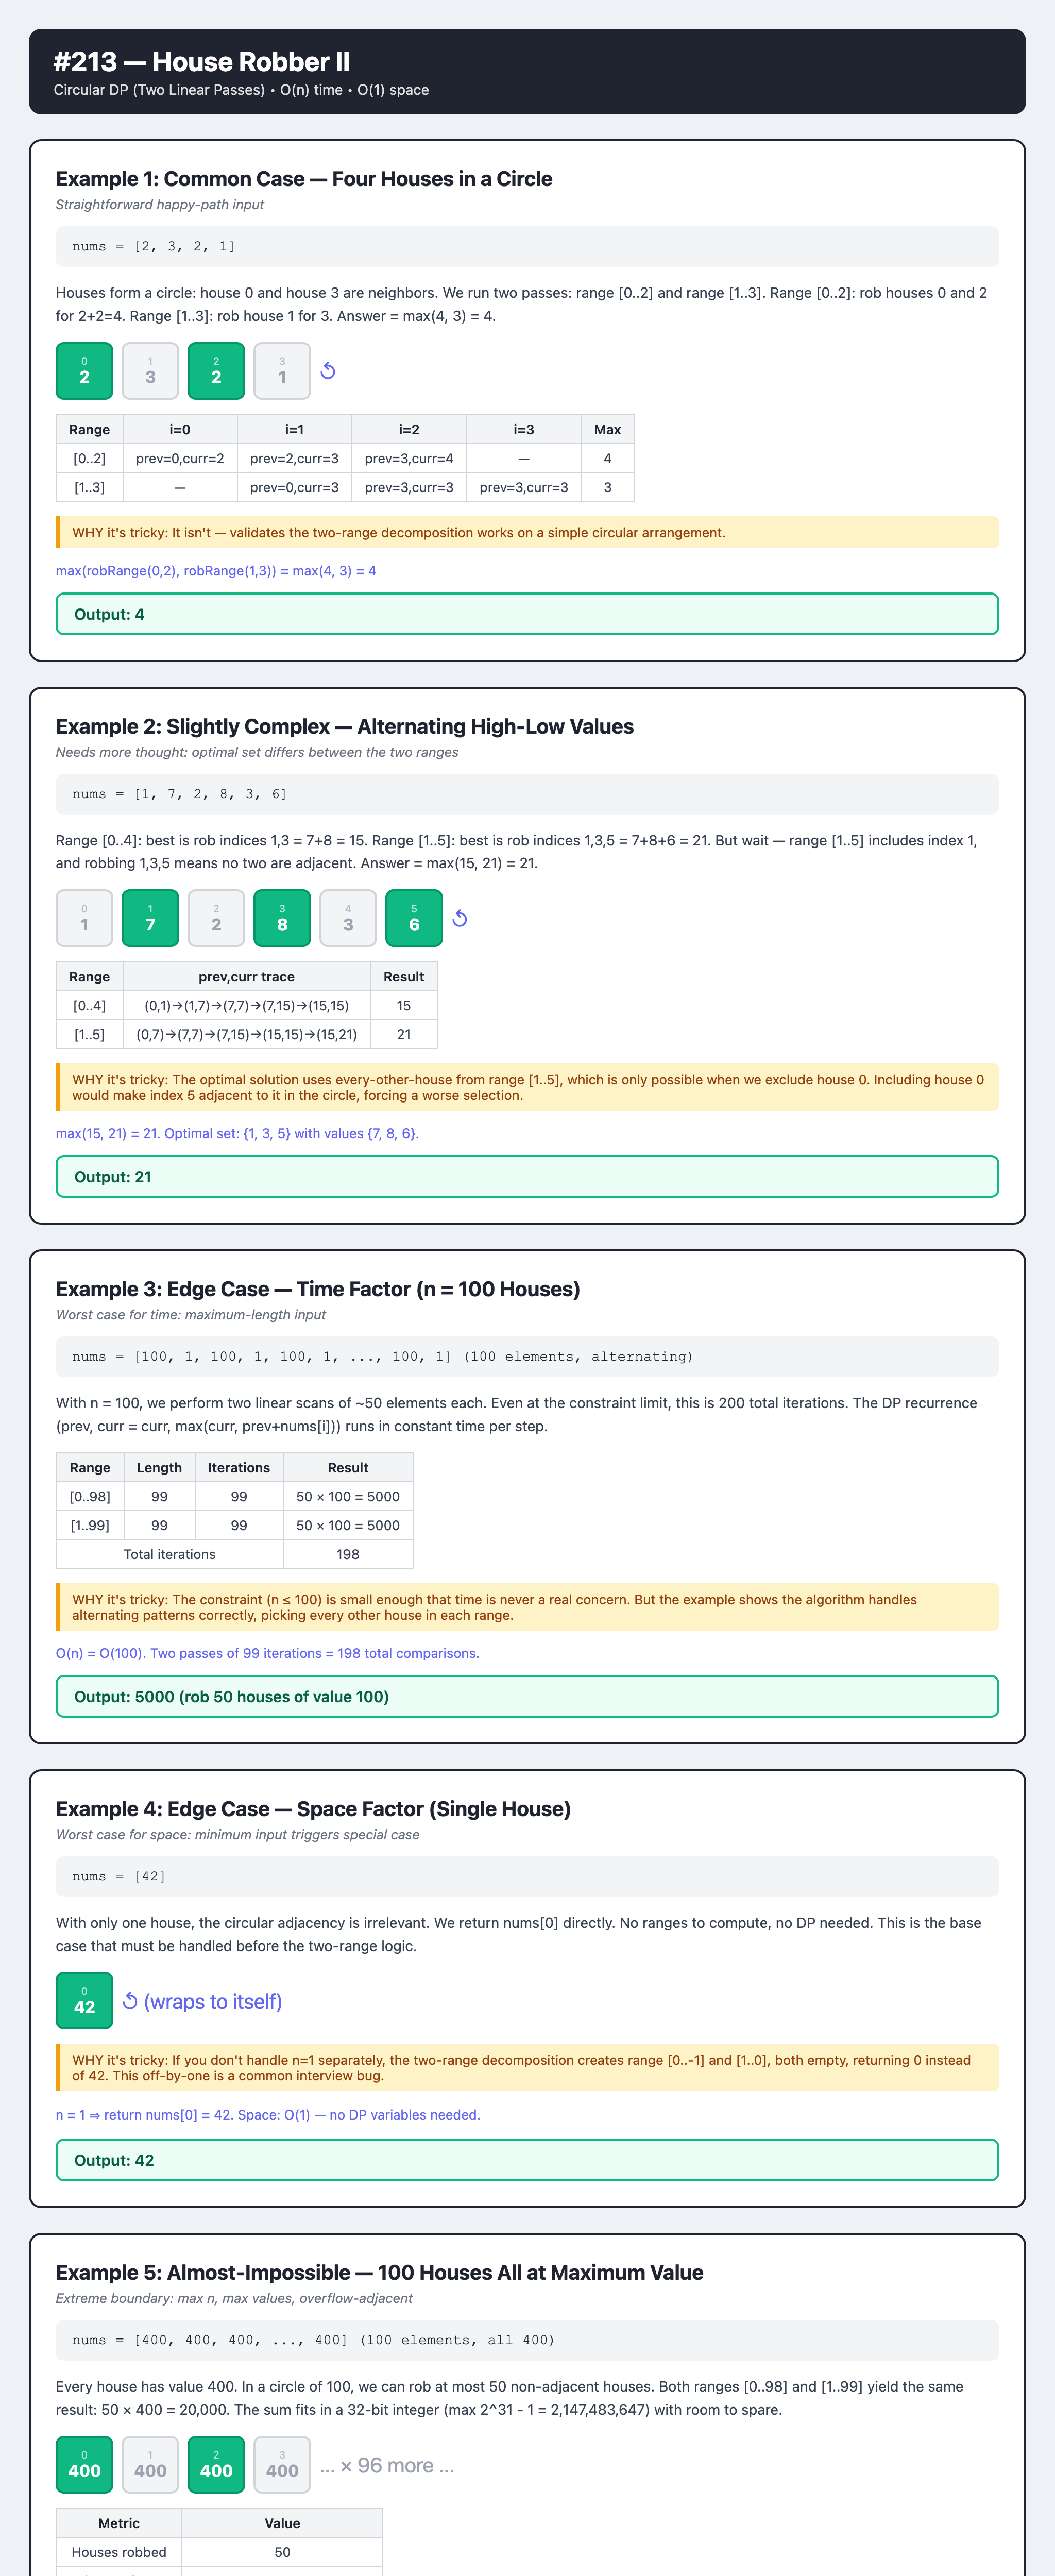